# 准备数据

In [23]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [1]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [2]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [3]:
# 设置任务参数
name = "demo"
index_symbol: str = "000300.SSE"
start: str = "2008-01-01"
end: str = "2023-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [4]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [5]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_fill_na,
    process_cs_norm
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [6]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [ ]:
df

In [8]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period = ("2008-01-01", "2014-12-31"),
    valid_period = ("2015-01-01", "2016-12-31"),
    test_period = ("2017-01-01", "2020-8-31"),
)

In [9]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

In [10]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [ ]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=20)

In [ ]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

In [13]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [13]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lgb_model import LgbModel

In [14]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [15]:
# 创建模型对象
model: AlphaModel = LgbModel(seed=42)

In [16]:
# 使用数据集训练模型
model.fit(dataset)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.293935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32797
[LightGBM] [Info] Number of data points in the train set: 510579, number of used features: 158
[LightGBM] [Info] Start training from score -0.000000
[1]	train's l2: 0.995334	valid's l2: 0.995644
Training until validation scores don't improve for 50 rounds
[2]	train's l2: 0.994069	valid's l2: 0.994485
[3]	train's l2: 0.993011	valid's l2: 0.99385
[4]	train's l2: 0.991933	valid's l2: 0.993198
[5]	train's l2: 0.991025	valid's l2: 0.99265
[6]	train's l2: 0.990191	valid's l2: 0.992144
[7]	train's l2: 0.989366	valid's l2: 0.991643
[8]	train's l2: 0.988665	valid's l2: 0.991289
[9]	train's l2: 0.988017	valid's l2: 0.991359
[10]	train's l2: 0.987364	valid's l2: 0.991405
[11]	train's l2: 0.986761	valid's l2: 0.991372
[12]	train's l2: 0.986141	valid's l2: 0.9912
[13]	train's l2: 0.985639	valid's l2: 0.99

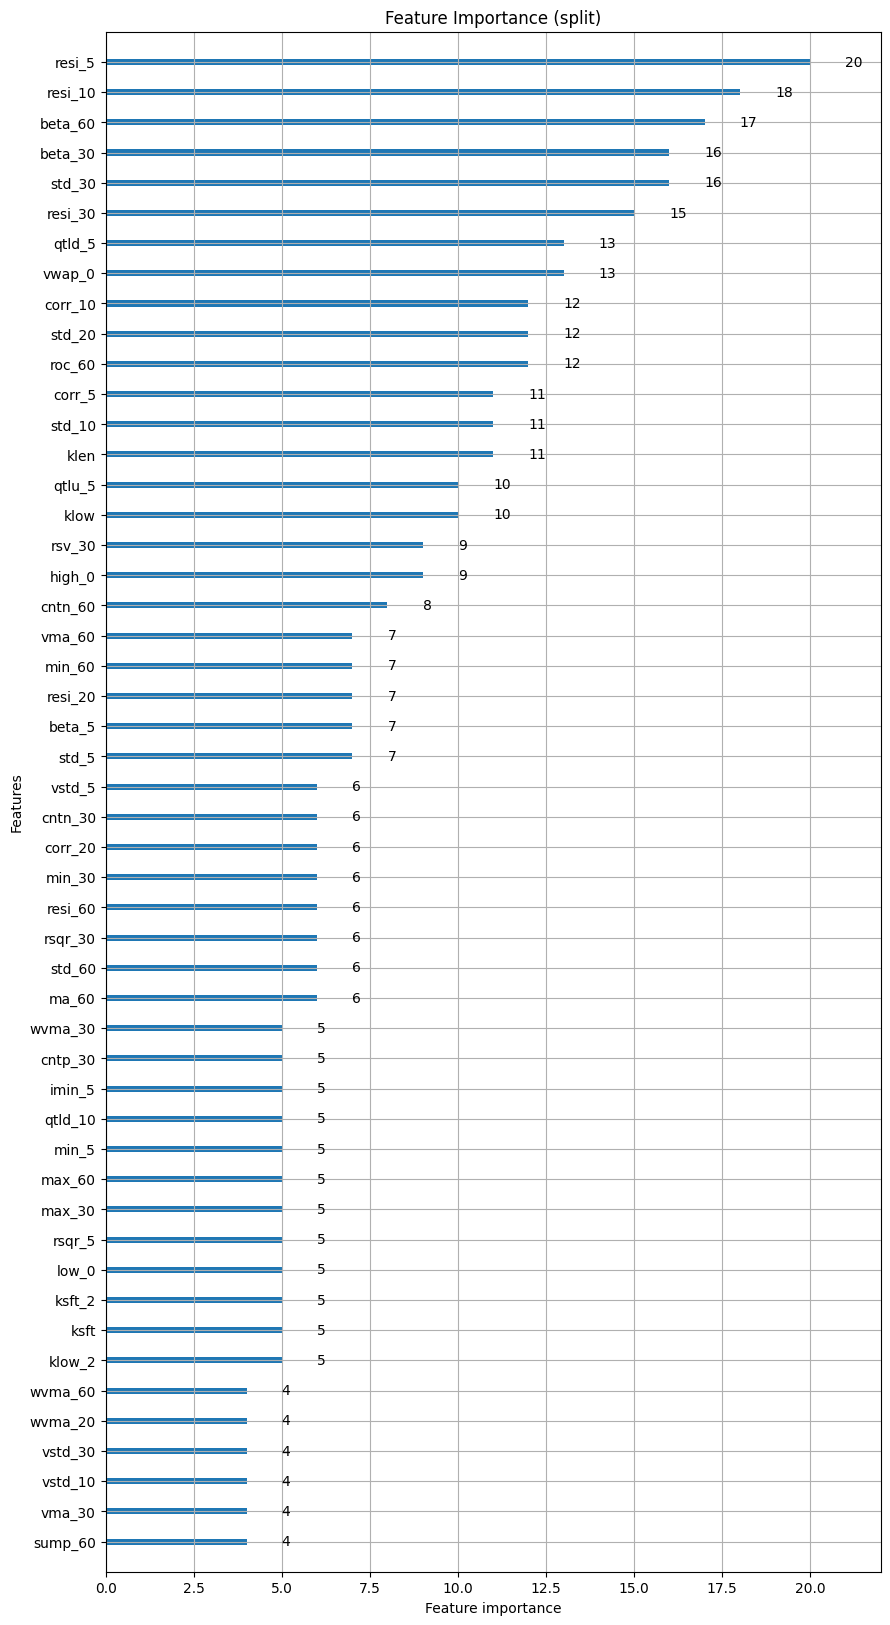

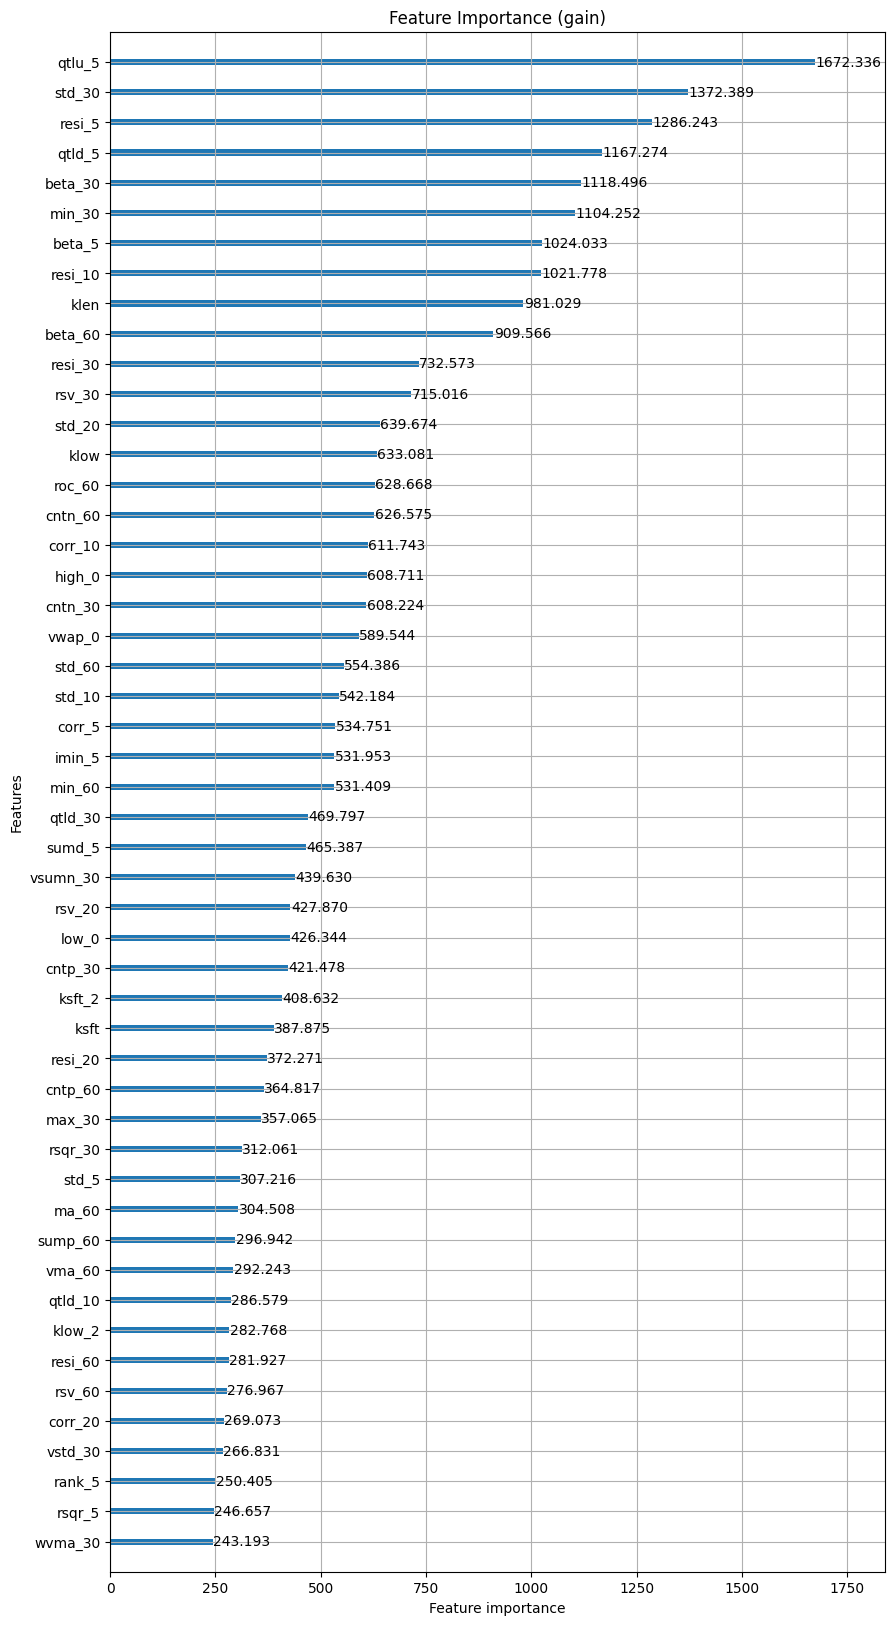

In [17]:
# 查看模型细节
model.detail()

In [18]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [19]:
model: AlphaModel = lab.load_model(name)

In [20]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.1% entries from factor data: 1.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-2.865719,0.021604,-0.089275,0.107621,26490,10.011338
2,-0.627738,0.050924,-0.046297,0.026353,26450,9.996221
3,-0.492027,0.072083,-0.030380,0.023720,26458,9.999244
4,-0.439727,0.084952,-0.018270,0.023185,26474,10.005291
5,-0.419218,0.105164,-0.007967,0.023008,26482,10.008314
6,-0.347023,0.131507,0.001831,0.021815,26469,10.003401
7,-0.131267,0.146012,0.012079,0.022185,26468,10.003023
8,-0.069368,0.176949,0.024313,0.024519,26416,9.983371
9,-0.035450,0.211112,0.041726,0.027788,26442,9.993197


Returns Analysis


,1D,5D,10D
Ann. alpha,0.948,0.407,0.200
beta,0.047,0.032,0.015
Mean Period Wise Return Top Quantile (bps),19.586,11.111,6.336
Mean Period Wise Return Bottom Quantile (bps),-21.039,-10.801,-4.739
Mean Period Wise Spread (bps),40.625,21.894,11.048


<Figure size 640x480 with 0 Axes>

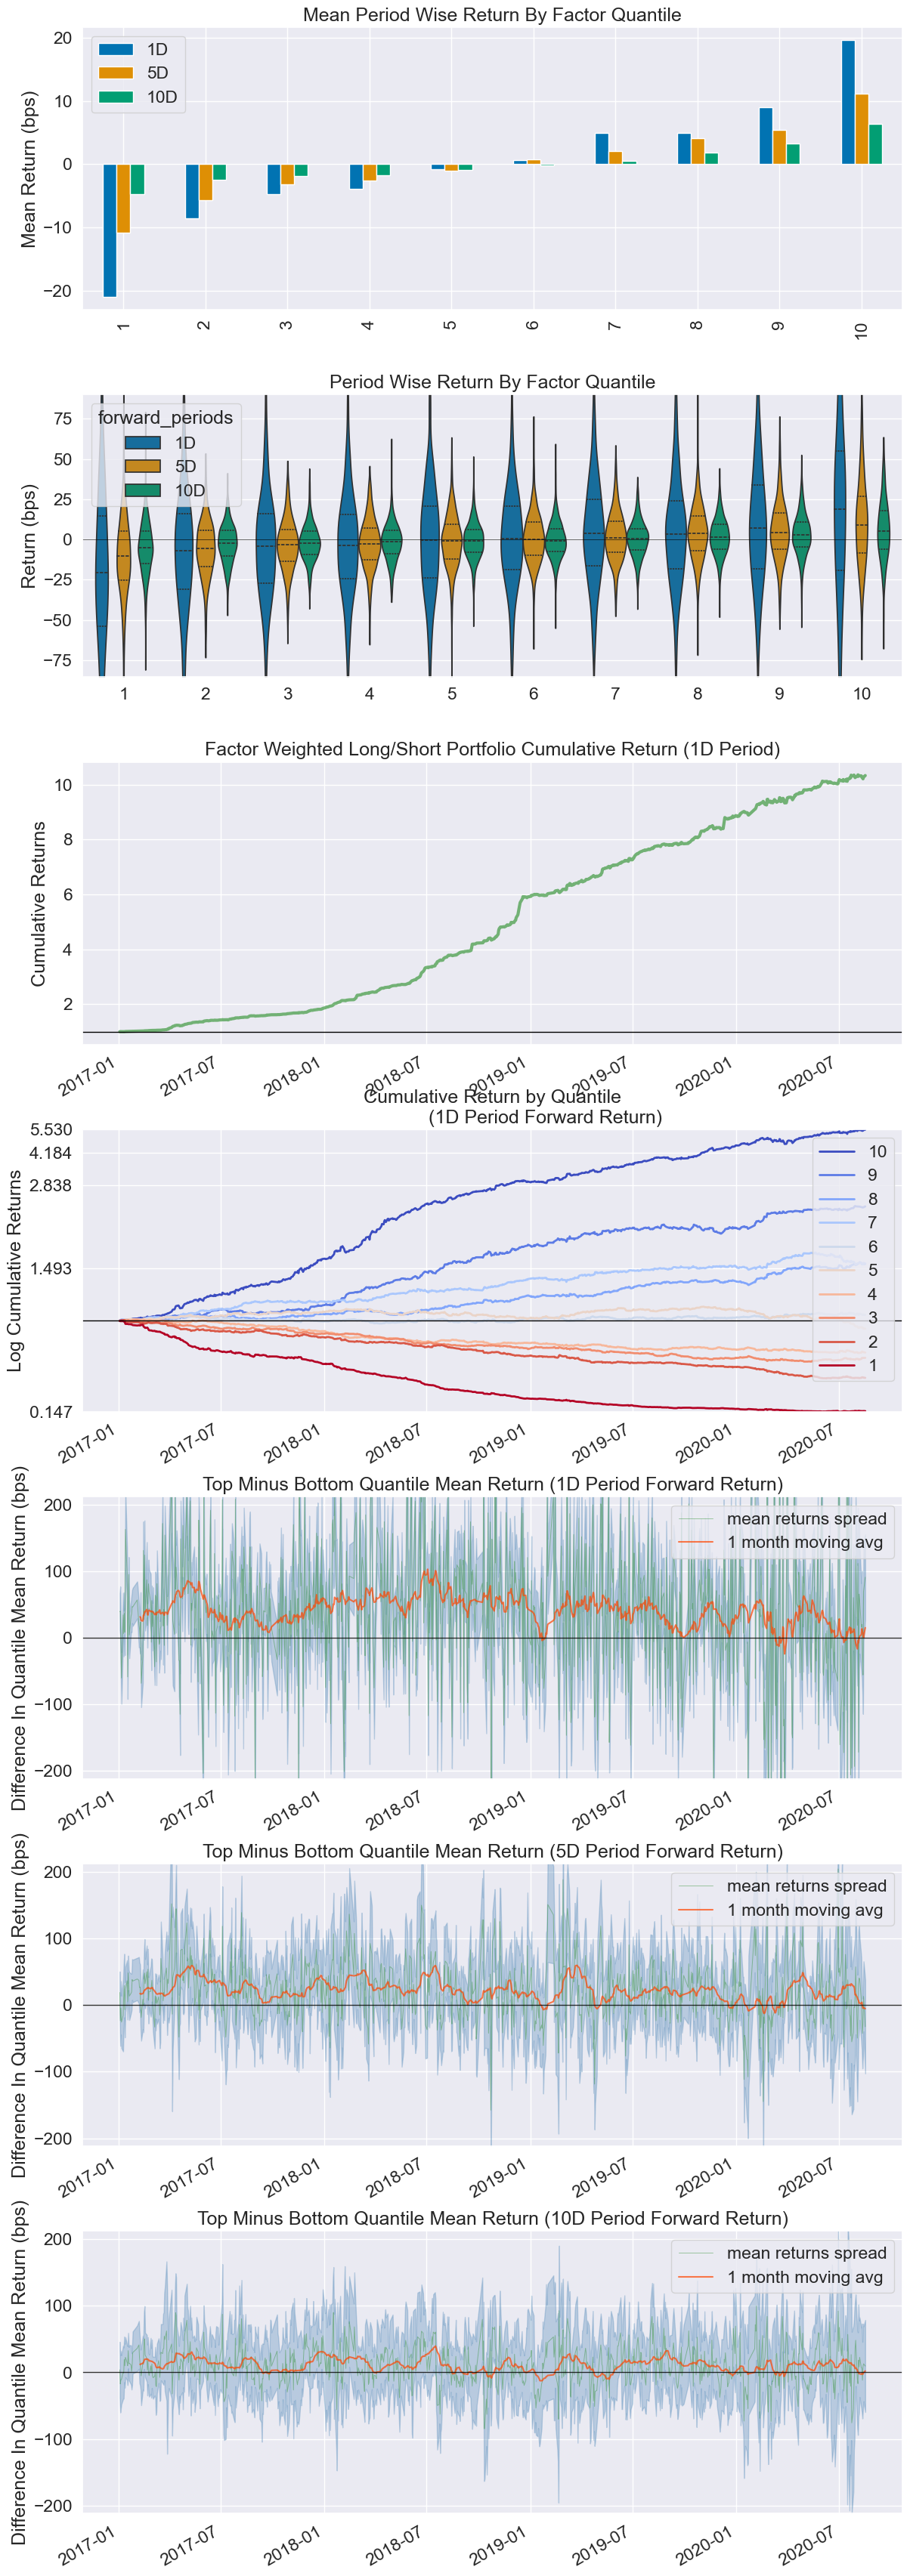

Information Analysis


,1D,5D,10D
IC Mean,0.063,0.067,0.047
IC Std.,0.129,0.123,0.113
Risk-Adjusted IC,0.494,0.543,0.412
t-stat(IC),14.657,16.127,12.236
p-value(IC),0.000,0.000,0.000
IC Skew,0.207,0.210,0.029
IC Kurtosis,0.646,0.071,-0.104


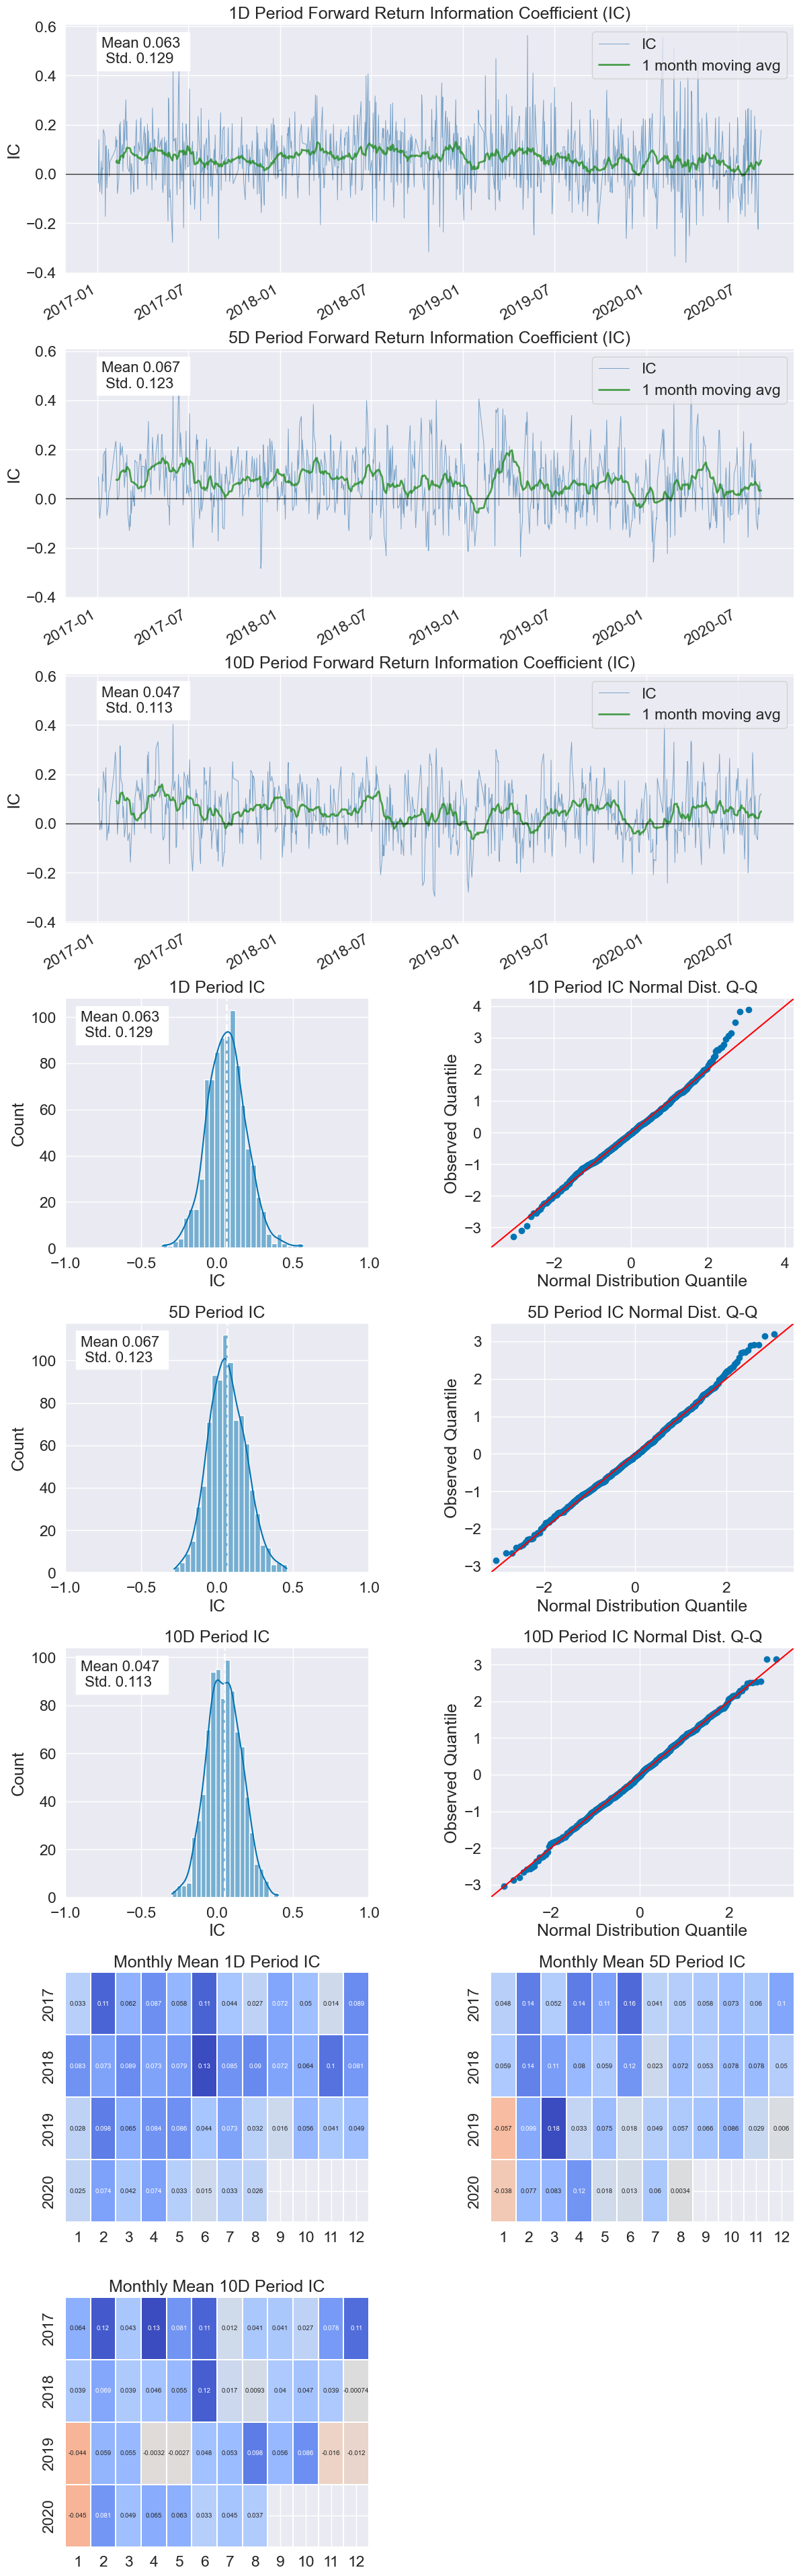

c:\Python313\Lib\site-packages\alphalens\utils.py:928: UserWarning:

Skipping return periods that aren't exact multiples of days.



Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.585,0.816,0.842
Quantile 2 Mean Turnover,0.754,0.869,0.881
Quantile 3 Mean Turnover,0.800,0.878,0.886
Quantile 4 Mean Turnover,0.824,0.886,0.895
Quantile 5 Mean Turnover,0.822,0.885,0.890
Quantile 6 Mean Turnover,0.820,0.880,0.884
Quantile 7 Mean Turnover,0.817,0.873,0.882
Quantile 8 Mean Turnover,0.800,0.878,0.888
Quantile 9 Mean Turnover,0.763,0.878,0.885
Quantile 10 Mean Turnover,0.537,0.809,0.828


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.563,0.108,0.077


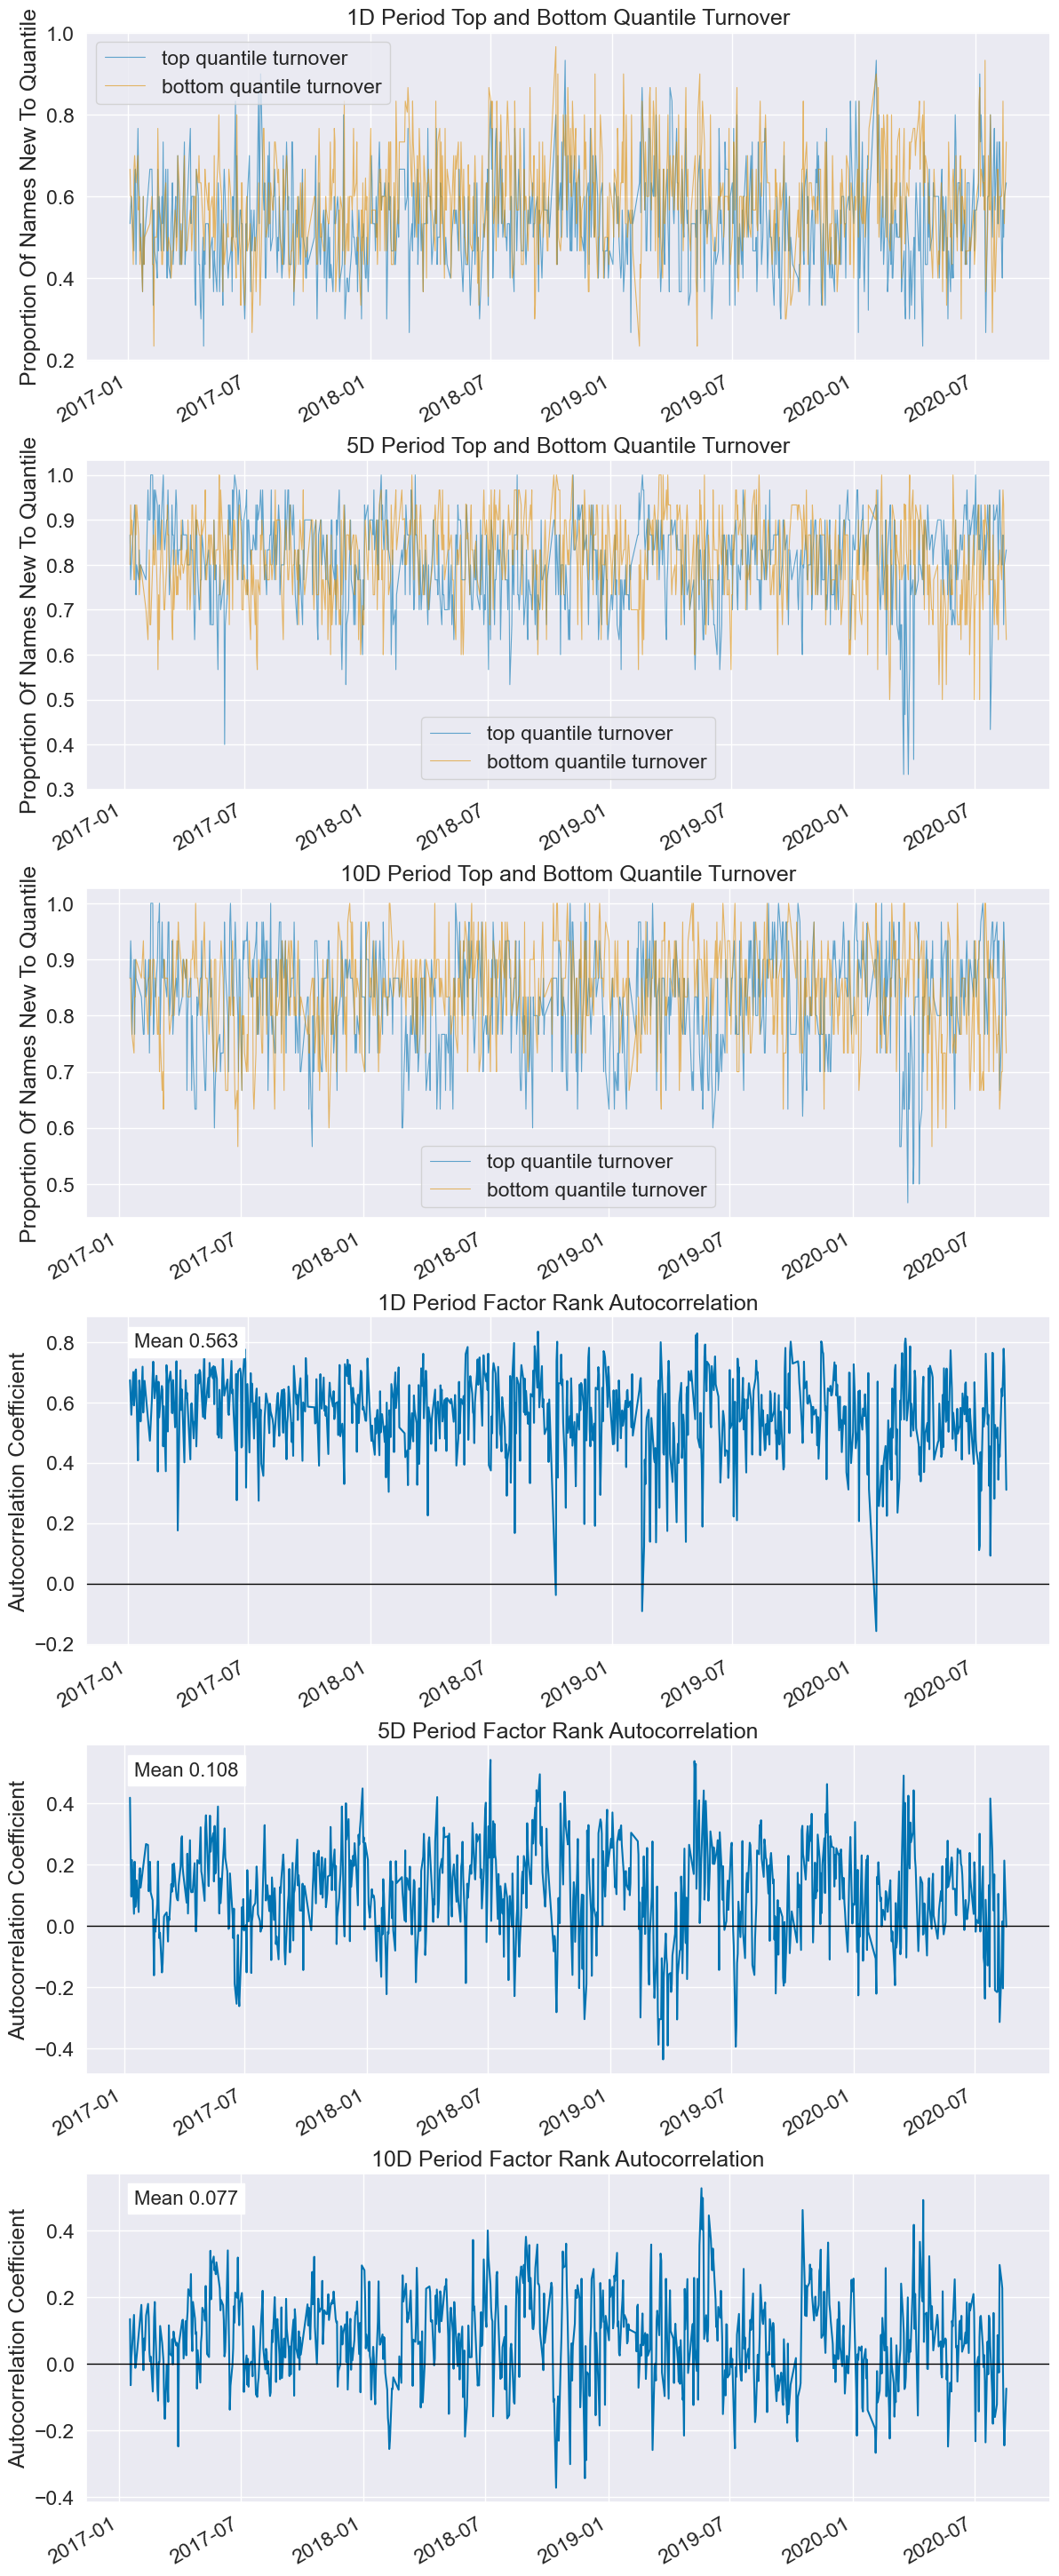

In [24]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [22]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [5]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [6]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [7]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [8]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2017, 1, 1),
    end=datetime(2020, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [9]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2025-03-26 19:33:58 开始加载历史数据


100%|██████████| 819/819 [00:04<00:00, 200.32it/s]

2025-03-26 19:34:02 部分合约历史数据为空：['000562.SZSE', '600087.SSE', '688187.SSE', '300999.SZSE', '300919.SZSE', '600905.SSE', '688041.SSE', '600591.SSE', '601728.SSE', '600001.SSE', '600786.SSE', '300957.SZSE', '601825.SSE', '601268.SSE', '000527.SZSE', '601868.SSE', '600832.SSE', '688223.SSE', '000024.SZSE', '301269.SZSE', '600102.SSE', '605499.SSE', '688303.SSE', '688271.SSE', '600941.SSE', '600357.SSE', '300979.SZSE', '600938.SSE', '601059.SSE', '300866.SZSE', '300896.SZSE', '688065.SSE', '601299.SSE', '600631.SSE', '601995.SSE', '605117.SSE', '001289.SZSE', '300888.SZSE']
2025-03-26 19:34:02 所有历史数据加载完成
2025-03-26 19:34:02 策略初始化完成
2025-03-26 19:34:02 开始回放历史数据


2025-03-26 19:34:06 历史数据回放结束
2025-03-26 19:34:06 开始计算逐日盯市盈亏
2025-03-26 19:34:06 逐日盯市盈亏计算完成
2025-03-26 19:34:06 开始计算策略统计指标
2025-03-26 19:34:06 ------------------------------
2025-03-26 19:34:06 首个交易日：  2017-01-03
2025-03-26 19:34:06 最后交易日：  2020-07-31
2025-03-26 19:34:06 总交易日：  871
2025-03-26 19:34:06 盈利交易日：  474
2025-03-26 19:34:06 亏损交易日：  396
2025-03-26 19:34:06 起始资金：  100,000,000.00
2025-03-26 19:34:06 结束资金：  281,492,949.01
2025-03-26 19:34:06 总收益率：  181.49%
2025-03-26 19:34:06 年化收益：  50.01%
2025-03-26 19:34:06 最大回撤:   -46,585,827.60
2025-03-26 19:34:06 百分比最大回撤: -23.22%
2025-03-26 19:34:06 最长回撤天数:   27
2025-03-26 19:34:06 总盈亏：  181,492,949.01
2025-03-26 19:34:06 总手续费：  19,240,820.57
2025-03-26 19:34:06 总成交金额：  25,680,978,346.93
2025-03-26 19:34:06 总成交笔数：  4625
2025-03-26 19:34:06 日均盈亏：  208,373.08
2025-03-26 19:34:06 日均手续费：  22,090.49
2025-03-26 19:34:06 日均成交金额：  29,484,475.71
2025-03-26 19:34:06 日均成交笔数：  5.309988518943743
2025-03-26 19:34:06 日均收益率：  0.13%
2025-03-26 19:34:06 收益标准差： 

In [10]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)